# Análisis exploratorio de datos: diamantes

Recorrido completo de EDA sobre 53.940 diamantes: detección de valores imposibles, outliers validados con criterio físico, distribuciones, correlaciones, ingeniería de variables y selección de las más relevantes para predecir el precio.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Configuración visual
sns.set(style="whitegrid")

### 1. CARGA DE DATOS

In [3]:
print("--- CARGANDO DATASET ---")
df = sns.load_dataset('diamonds')
print(f"Filas iniciales: {len(df)}")
print("-" * 60)

--- CARGANDO DATASET ---
Filas iniciales: 53940
------------------------------------------------------------


### 2. ANÁLISIS DE VARIABLES Y TIPOS


>>> PUNTO 2: ANÁLISIS DE VARIABLES
Variable Objetivo (Target): price
Variables Predictoras: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']

Tipos de datos:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

TIPO DE PROBLEMA: REGRESIÓN (Predecir valor continuo).
Generando gráfico de relaciones iniciales con definiciones de variables...


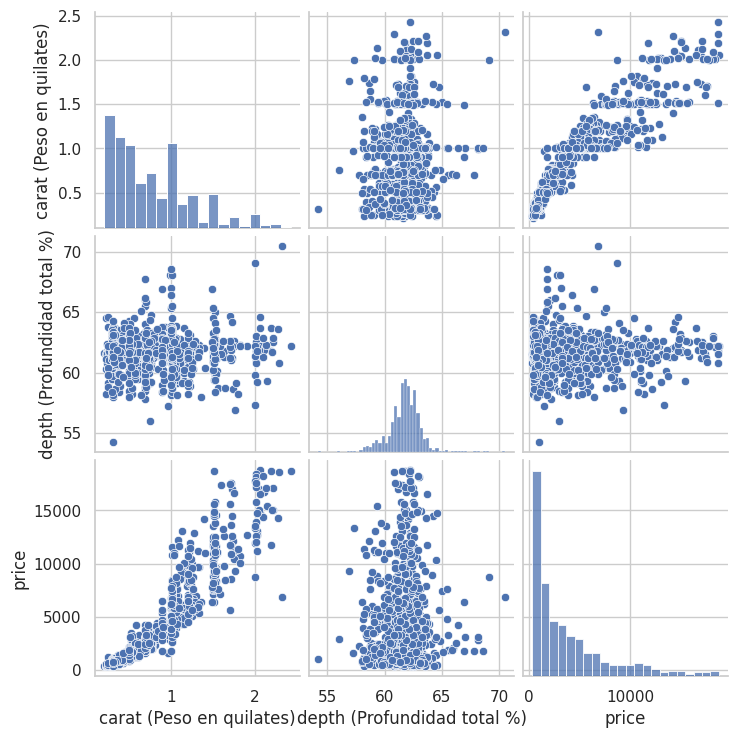

------------------------------------------------------------


In [13]:
print("\n>>> PUNTO 2: ANÁLISIS DE VARIABLES")

# - Variables Predictoras y Objetivo
target = 'price'
features = [c for c in df.columns if c != target]

print(f"Variable Objetivo (Target): {target}")
print(f"Variables Predictoras: {features}")

# - Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# - Tipo de Problema
# Al ser 'price' continua y numérica, es Regresión.
print("\nTIPO DE PROBLEMA: REGRESIÓN (Predecir valor continuo).")

# - Representación gráfica inicial (Muestra rápida)
print("Generando gráfico de relaciones iniciales con definiciones de variables...")
# Usamos un sample para que no tarde mucho en pintar 50k puntos
# Definiciones: 'carat' es el peso del diamante en quilates; 'depth' es la profundidad total porcentual del diamante.
g = sns.pairplot(df.sample(1000)[['carat', 'depth', 'price']])
# Añadir definiciones a las etiquetas de los ejes del pairplot
for ax in g.axes.flat:
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()
    if xlabel == 'carat':
        ax.set_xlabel('carat (Peso en quilates)')
    elif xlabel == 'depth':
        ax.set_xlabel('depth (Profundidad total %)')
    if ylabel == 'carat':
        ax.set_ylabel('carat (Peso en quilates)')
    elif ylabel == 'depth':
        ax.set_ylabel('depth (Profundidad total %)')
plt.show()
print("-" * 60)

### 3. DATOS MISSINGS (Limpieza Física)

In [5]:
print("\n>>> PUNTO 3: DATOS MISSINGS")

# Detectamos "Missings Ocultos" (Ceros en dimensiones)
# Argumento: Un diamante no puede medir 0mm. Es un dato perdido.
filtro_ceros = (df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)
num_ceros = filtro_ceros.sum()

print(f"Detectados {num_ceros} valores nulos (ceros físicos).")
print("ARGUMENTO: Al ser un error físico imposible y representar una cantidad ínfima")
print("de datos (<0.05%), eliminarlos es más seguro que imputar una media inventada.")

df = df[~filtro_ceros].copy()
print(f"Filas tras limpieza: {len(df)}")
print("-" * 60)


>>> PUNTO 3: DATOS MISSINGS
Detectados 20 valores nulos (ceros físicos).
ARGUMENTO: Al ser un error físico imposible y representar una cantidad ínfima
de datos (<0.05%), eliminarlos es más seguro que imputar una media inventada.
Filas tras limpieza: 53920
------------------------------------------------------------


### 4. CODIFICAR VARIABLES CATEGÓRICAS

In [6]:
print("\n>>> PUNTO 4: CODIFICACIÓN ONE-HOT")
# Variables: cut, color, clarity
# drop_first=True evita la trampa de la variable dummy (multicolinealidad)

df_encoded = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)

print("Variables codificadas (Primeras columnas nuevas):")
print(df_encoded.filter(like='cut_').head(2))
print("-" * 60)


>>> PUNTO 4: CODIFICACIÓN ONE-HOT
Variables codificadas (Primeras columnas nuevas):
   cut_Premium  cut_Very Good  cut_Good  cut_Fair
0        False          False     False     False
1         True          False     False     False
------------------------------------------------------------


### 5. DISTRIBUCIÓN (SKEWNESS Y KURTOSIS)


>>> PUNTO 5: DISTRIBUCIÓN, ASIMETRÍA Y CURTOSIS
Variable 'price': Skewness=1.62 | Kurtosis=2.18


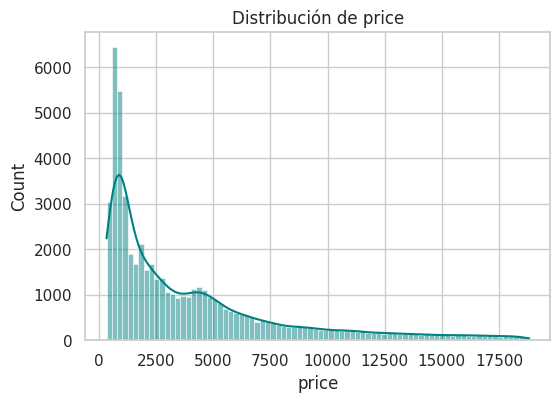

Variable 'carat': Skewness=1.12 | Kurtosis=1.26


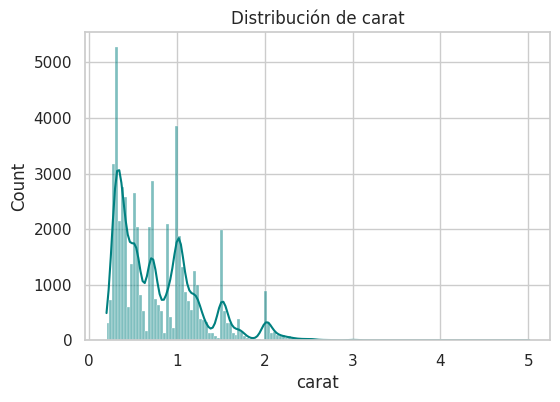

CONCLUSIÓN: 'price' tiene asimetría positiva alta y curtosis alta (pico muy alto).
------------------------------------------------------------


In [7]:
print("\n>>> PUNTO 5: DISTRIBUCIÓN, ASIMETRÍA Y CURTOSIS")

vars_analisis = ['price', 'carat']

for col in vars_analisis:
    skew = df[col].skew()
    kurt = df[col].kurt()
    print(f"Variable '{col}': Skewness={skew:.2f} | Kurtosis={kurt:.2f}")

    # Gráfico
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribución de {col}')
    plt.show()
    #Skewness (Asimetría): Mide cuán simétrica es la distribución de los datos
    #Kurtosis (Curtosis): Mide el 'pico' de la distribución y la 'pesadez' de sus colas (es decir, la presencia de valores atípicos).

print("CONCLUSIÓN: 'price' tiene asimetría positiva alta y curtosis alta (pico muy alto).")
print("-" * 60)

### 6. VALORES ANÓMALOS (OUTLIERS HÍBRIDOS)


>>> PUNTO 6: OUTLIERS (ENFOQUE HÍBRIDO)
Generando gráfico ANTES de limpieza...


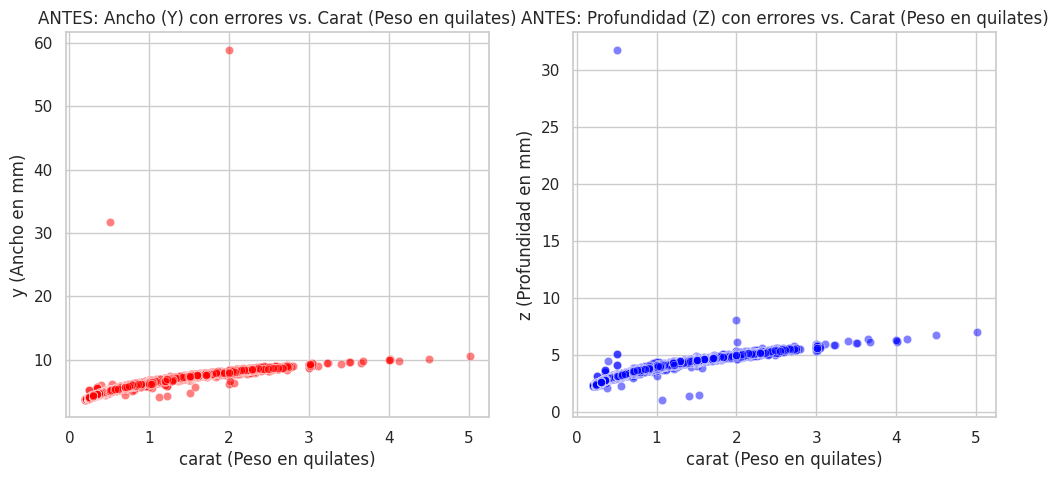

Se han eliminado 18 registros erróneos.
Generando gráfico DE COMPROBACIÓN (DESPUÉS)...


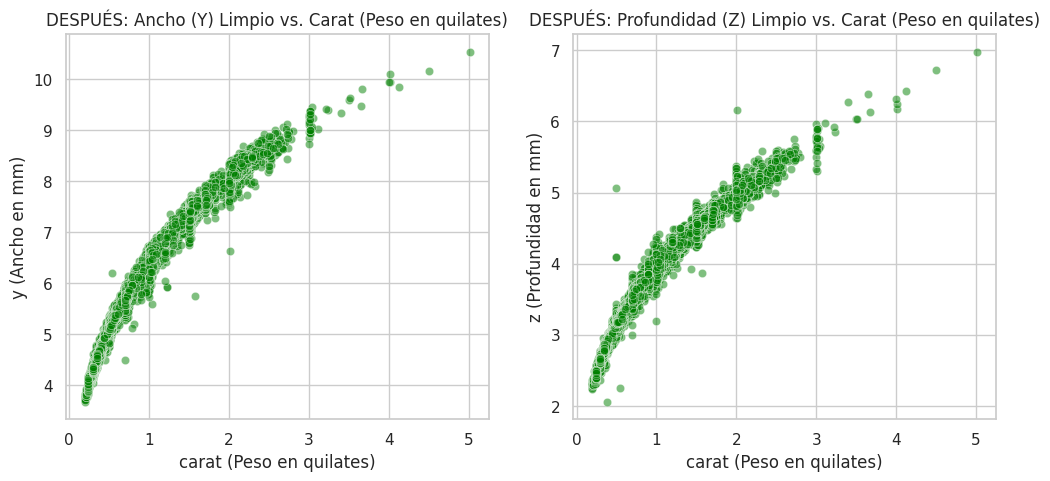

CONCLUSIÓN: Confirmación visual de que los errores físicos han desaparecido.
------------------------------------------------------------


In [16]:
print("\n>>> PUNTO 6: OUTLIERS (ENFOQUE HÍBRIDO)")

# 1. Gráfico visual ANTES de limpiar
print("Generando gráfico ANTES de limpieza...")
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x='carat', y='y', data=df, ax=ax[0], color='red', alpha=0.5).set_title('ANTES: Ancho (Y) con errores vs. Carat (Peso en quilates)')
ax[0].set_xlabel('carat (Peso en quilates)')
ax[0].set_ylabel('y (Ancho en mm)')
sns.scatterplot(x='carat', y='z', data=df, ax=ax[1], color='blue', alpha=0.5).set_title('ANTES: Profundidad (Z) con errores vs. Carat (Peso en quilates)')
ax[1].set_xlabel('carat (Peso en quilates)')
ax[1].set_ylabel('z (Profundidad en mm)')
plt.show()

# 2. Validación Matemática y Limpieza
df_encoded['volumen'] = df['x'] * df['y'] * df['z'] # Usamos df original para x,y,z
df_encoded['ratio_fisico'] = df_encoded['volumen'] / df_encoded['carat']

# Explicación del Ratio Físico para eliminar outliers:
# El 'ratio_fisico' (volumen / quilates) es una métrica que representa la "densidad" del diamante.
# Dado que los diamantes tienen una densidad relativamente constante, un ratio muy alto o muy bajo
# indica que hay un error en las mediciones (x, y, z o carat), o un diamante con propiedades físicas imposibles.
# Se establecen umbrales (100 y 300) para este ratio, así como para las dimensiones físicas (y, z < 20mm),
# para filtrar y eliminar registros que son físicamente anómalos o imposibles.
mask_limpio = (df_encoded['y'] < 20) & (df_encoded['z'] < 20) & \
              (df_encoded['ratio_fisico'] > 100) & (df_encoded['ratio_fisico'] < 300)

n_outliers = len(df_encoded) - mask_limpio.sum()
df_clean = df_encoded[mask_limpio].copy()

print(f"Se han eliminado {n_outliers} registros erróneos.")

# 3. Gráfico visual DESPUÉS de limpiar (SOLICITADO)
print("Generando gráfico DE COMPROBACIÓN (DESPUÉS)...")
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Usamos df_clean para verificar que ya no están los puntos disparados
sns.scatterplot(x='carat', y='y', data=df_clean, ax=ax[0], color='green', alpha=0.5).set_title('DESPUÉS: Ancho (Y) Limpio vs. Carat (Peso en quilates)')
ax[0].set_xlabel('carat (Peso en quilates)')
ax[0].set_ylabel('y (Ancho en mm)')
sns.scatterplot(x='carat', y='z', data=df_clean, ax=ax[1], color='green', alpha=0.5).set_title('DESPUÉS: Profundidad (Z) Limpio vs. Carat (Peso en quilates)')
ax[1].set_xlabel('carat (Peso en quilates)')
ax[1].set_ylabel('z (Profundidad en mm)')
plt.show()

print("CONCLUSIÓN: Confirmación visual de que los errores físicos han desaparecido.")
print("-" * 60)

### 7. CORRELACIÓN Y VARIABLES PRESCINDIBLES


>>> PUNTO 7: CORRELACIÓN

Variables PRESCINDIBLES (Correlación < 0.05 con price):
['cut_Fair', 'clarity_SI1', 'color_G', 'cut_Very Good', 'clarity_I1', 'cut_Good', 'clarity_VS2', 'clarity_VS1', 'depth', 'color_F']
CONCLUSIÓN: Estas variables tienen un impacto nulo en el precio y serán eliminadas.
... Eliminando columnas: ['cut_Fair', 'clarity_SI1', 'color_G', 'cut_Very Good', 'clarity_I1', 'cut_Good', 'clarity_VS2', 'clarity_VS1', 'depth', 'color_F'] ...
Variables eliminadas correctamente para no ensuciar el análisis posterior.

Recalculando la matriz de correlación sin las variables prescindibles...


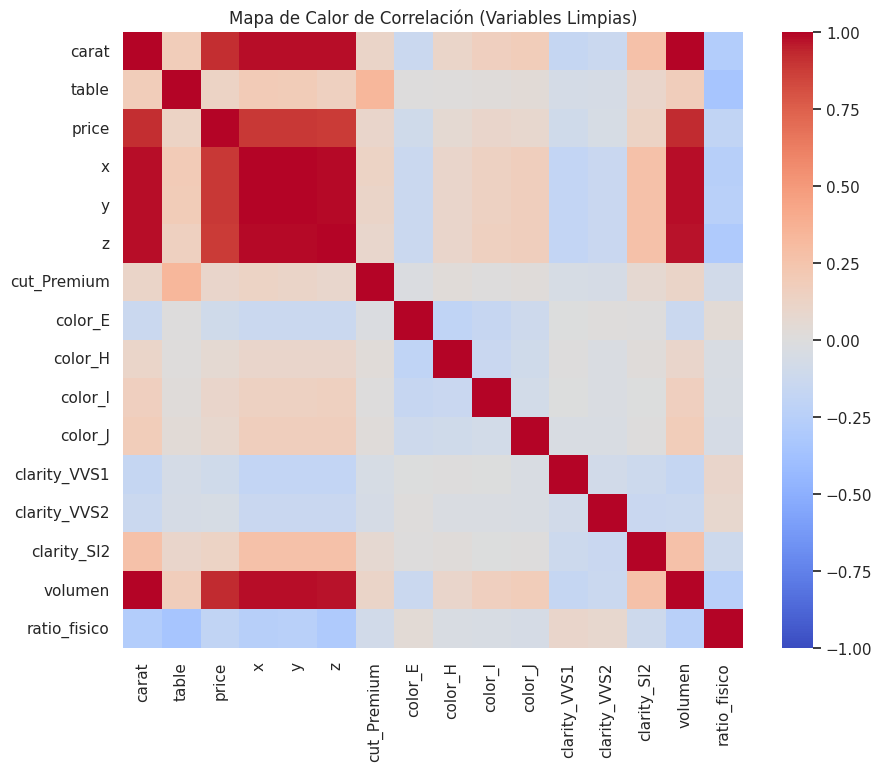

Top 5 Variables más correlacionadas con Precio (tras limpieza):
price      1.000000
volumen    0.923735
carat      0.921571
y          0.889000
x          0.887328
Name: price, dtype: float64
------------------------------------------------------------


In [9]:
print("\n>>> PUNTO 7: CORRELACIÓN")


# Calcular la matriz de correlación inicial para identificar 'prescindibles'
corr_matrix_initial = df_clean.corr()

# Identificar Importantes y Prescindibles (basado en la correlación inicial)
correlaciones_initial = corr_matrix_initial['price'].sort_values(ascending=False)

# Variables con correlación cercana a 0
umbral = 0.05
prescindibles = correlaciones_initial[abs(correlaciones_initial) < umbral].index.tolist()

print("\nVariables PRESCINDIBLES (Correlación < 0.05 con price):")
if prescindibles:
    print(prescindibles)
    print("CONCLUSIÓN: Estas variables tienen un impacto nulo en el precio y serán eliminadas.")

    # ELIMINACIÓN DE VARIABLES
    print(f"... Eliminando columnas: {prescindibles} ...")
    df_clean = df_clean.drop(columns=prescindibles)
    print("Variables eliminadas correctamente para no ensuciar el análisis posterior.")

    # Recalcular la matriz de correlación DESPUÉS de eliminar variables
    print("\nRecalculando la matriz de correlación sin las variables prescindibles...")
    corr_matrix_cleaned = df_clean.corr()

    # Mapa de calor con las variables limpias (GRÁFICO LIMPIO)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix_cleaned, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Mapa de Calor de Correlación (Variables Limpias)')
    plt.show()

    # Identificar Importantes (de las variables restantes)
    correlaciones_cleaned = corr_matrix_cleaned['price'].sort_values(ascending=False)
    print("Top 5 Variables más correlacionadas con Precio (tras limpieza):")
    print(correlaciones_cleaned.head(5))

else:
    print("Todas las variables tienen relevancia significativa.")
    # Si no se eliminaron variables, mostramos la matriz de correlación inicial
    corr_matrix_cleaned = corr_matrix_initial
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix_cleaned, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Mapa de Calor de Correlación')
    plt.show()
    print("Top 5 Variables más correlacionadas con Precio:")
    print(correlaciones_initial.head(5))

print("-" * 60)

### 8. INGENIERÍA DE VARIABLES


>>> PUNTO 8: INGENIERÍA DE VARIABLES
Correlación Nueva Variable 'volumen' vs 'price': 0.9237


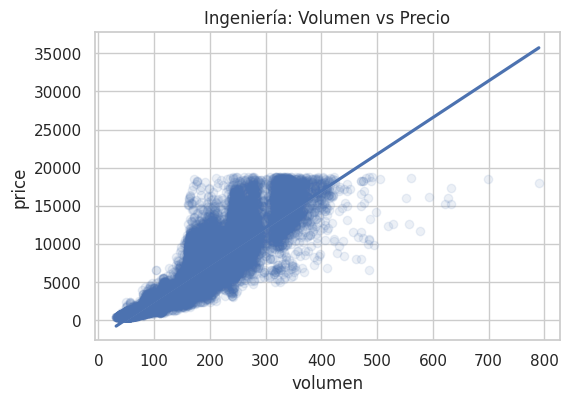

------------------------------------------------------------


In [10]:
print("\n>>> PUNTO 8: INGENIERÍA DE VARIABLES")

# Visualizamos importancia de 'volumen' (creada en paso 6)
corr_vol = df_clean[['price', 'volumen']].corr().iloc[0,1]
print(f"Correlación Nueva Variable 'volumen' vs 'price': {corr_vol:.4f}")

plt.figure(figsize=(6, 4))
sns.regplot(x='volumen', y='price', data=df_clean, scatter_kws={'alpha':0.1})
plt.title('Ingeniería: Volumen vs Precio')
plt.show()
print("-" * 60)

### 9. NORMALIZACIÓN Y COMPARACIÓN


>>> PUNTO 9: TRANSFORMACIÓN Y ESTANDARIZACIÓN
Comparación 'price':
ANTES:   Skew=1.62, Kurtosis=2.18
DESPUÉS: Skew=0.12, Kurtosis=-1.10


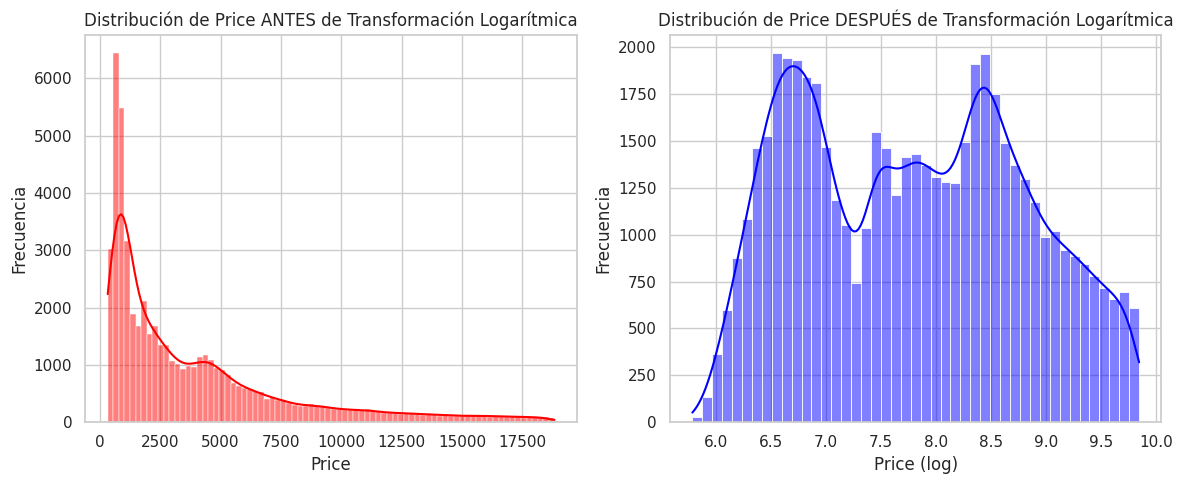


Estandarizando variables predictoras...
Variables estandarizadas: ['carat', 'table', 'x', 'y', 'z', 'volumen']
------------------------------------------------------------


In [15]:
print("\n>>> PUNTO 9: TRANSFORMACIÓN Y ESTANDARIZACIÓN")

# A) Transformación Logarítmica y COMPARACIÓN
skew_antes = df_clean['price'].skew()
kurt_antes = df_clean['price'].kurt()

df_clean['price_log'] = np.log1p(df_clean['price'])

skew_despues = df_clean['price_log'].skew()
kurt_despues = df_clean['price_log'].kurt()

print(f"Comparación 'price':")
print(f"ANTES:   Skew={skew_antes:.2f}, Kurtosis={kurt_antes:.2f}")
print(f"DESPUÉS: Skew={skew_despues:.2f}, Kurtosis={kurt_despues:.2f}")

# Gráficos de comparación antes y después de la transformación logarítmica
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['price'], kde=True, color='red')
plt.title('Distribución de Price ANTES de Transformación Logarítmica')
plt.xlabel('Price')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['price_log'], kde=True, color='blue')
plt.title('Distribución de Price DESPUÉS de Transformación Logarítmica')
plt.xlabel('Price (log)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


# B) Estandarización
print("\nEstandarizando variables predictoras...")
scaler = StandardScaler()

# Re-calculamos columnas numéricas disponibles (por si se borró alguna en el punto 7)
cols_scale = [c for c in df_clean.columns if c not in ['price', 'price_log', 'ratio_fisico'] and df_clean[c].dtype in ['float64', 'int64']]
# Nota: Excluimos categóricas one-hot (uint8/int) si queremos escalar solo medidas físicas,
# pero escalar todo suele ser estándar. Aquí nos centramos en las continuas.
# Filtramos explícitamente las físicas típicas si siguen existiendo:
cols_posibles = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volumen']
cols_a_escalar = [c for c in cols_posibles if c in df_clean.columns]

df_scaled = df_clean.copy()
df_scaled[cols_a_escalar] = scaler.fit_transform(df_clean[cols_a_escalar])

print(f"Variables estandarizadas: {cols_a_escalar}")
print("-" * 60)

### 10. MODELO E IMPORTANCIA


>>> PUNTO 10: MODELO DE MACHINE LEARNING
R2 Score (Precisión del Modelo): 0.9662

Ranking de Importancia:
        Variable      Peso
3              y  0.770550
13       volumen  0.750247
9        color_J  0.397505
2              x  0.393360
4              z  0.387614
8        color_I  0.266518
10  clarity_VVS1  0.266038
12   clarity_SI2  0.253444
0          carat  0.250041
11  clarity_VVS2  0.210097


/tmp/ipython-input-3748772635.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Variable', data=importancia, palette='viridis')


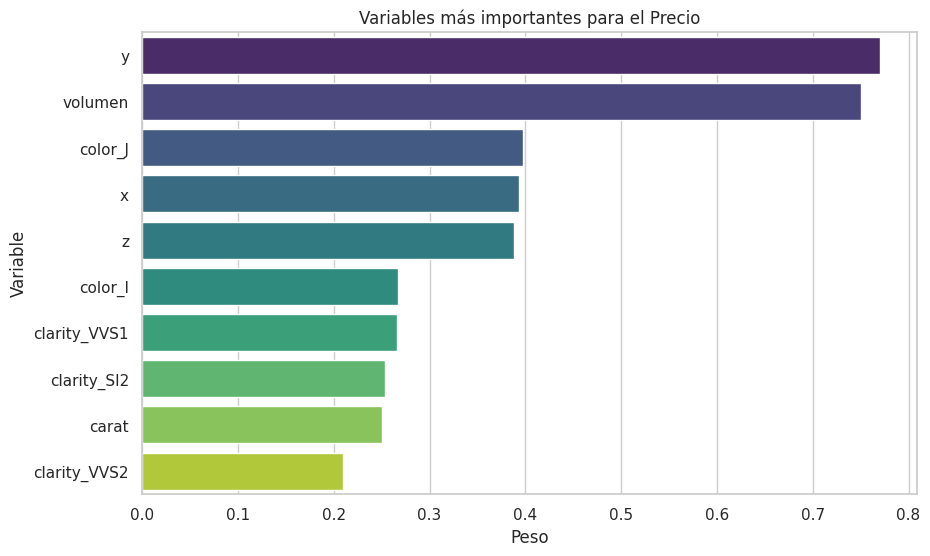


--- ANÁLISIS COMPLETADO ---


In [12]:
print("\n>>> PUNTO 10: MODELO DE MACHINE LEARNING")

# Predecimos logaritmo del precio
X = df_scaled.drop(['price', 'price_log', 'ratio_fisico'], axis=1, errors='ignore')
y = df_scaled['price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
score = model.score(X_test, y_test)

print(f"R2 Score (Precisión del Modelo): {score:.4f}")

# Ranking
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Peso': abs(model.coef_)
}).sort_values('Peso', ascending=False).head(10)

print("\nRanking de Importancia:")
print(importancia)

plt.figure(figsize=(10, 6))
sns.barplot(x='Peso', y='Variable', data=importancia, palette='viridis')
plt.title('Variables más importantes para el Precio')
plt.show()


#x (Length / Largo): Cuánto mide de largo (visto desde arriba).

#y (Width / Ancho): Cuánto mide de ancho (visto desde arriba).

#z (Depth / Profundidad o Alto): Cuánto mide de alto (desde la punta inferior "culet" hasta la mesa superior).